# TEST PID FMU

In [50]:
from pathlib import Path

from OMPython import ModelicaSystem

pkg = Path.cwd().parent / "ControlledPendulum/package.mo"
pkg_name = "ControlledPendulum"
model_name = "PID_Continuous"
model_str = f"{pkg_name}.{model_name}"

model = ModelicaSystem(str(pkg), model_str, commandLineOptions="--fmiFlags=s:cvode")
model.buildModel()

fmu_path = model.convertMo2Fmu(version="2.0", fmuType="cs")


Notification: Automatically loaded package Complex 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package ModelicaServices 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package Modelica 4.0.0 due to usage.




In [51]:
from fmpy import extract, instantiate_fmu, read_model_description

model_description = read_model_description(fmu_path)
unzipdir = extract(fmu_path)
fmu = instantiate_fmu(unzipdir, model_description)

LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF


In [52]:
vars = {var.name: var for var in model_description.modelVariables}
stop_time = 3.0
fmu.instantiate()
fmu.setupExperiment(startTime=0.0, stopTime=stop_time, tolerance=1e-6)
fmu.enterInitializationMode()

fmu.setReal([vars["uMin"].valueReference], [-1.0])
fmu.setReal([vars["uMax"].valueReference], [1.0])
fmu.exitInitializationMode()

LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF


0

In [53]:
vars

{'D.x': ModelVariable(name='D.x', type='Real'),
 'I.y': ModelVariable(name='I.y', type='Real'),
 'der(D.x)': ModelVariable(name='der(D.x)', type='Real'),
 'der(I.y)': ModelVariable(name='der(I.y)', type='Real'),
 'der(_D_outputAlias_u)': ModelVariable(name='der(_D_outputAlias_u)', type='Real'),
 'ref': ModelVariable(name='ref', type='Real'),
 'u': ModelVariable(name='u', type='Real'),
 'y': ModelVariable(name='y', type='Real'),
 'Nd': ModelVariable(name='Nd', type='Real'),
 'Td': ModelVariable(name='Td', type='Real'),
 'Ti': ModelVariable(name='Ti', type='Real'),
 'k': ModelVariable(name='k', type='Real'),
 'uMax': ModelVariable(name='uMax', type='Real'),
 'uMin': ModelVariable(name='uMin', type='Real')}

In [54]:
ref = 1
state = 0.0
dt = 0.05

t_vals = [0.0]
ref_vals = [1]
state_vals = [0.0]
u_vals = [0.0]

u = 0.0
t = 0.0

for step in range(int(stop_time / dt) - 1):
    print(f"step: {step}, state: {state:.2f}, control signal: {u:.2f}")
    fmu.setReal([vars["ref"].valueReference], [ref])
    fmu.setReal([vars["y"].valueReference], [state])
    fmu.doStep(currentCommunicationPoint=t, communicationStepSize=dt)
    u = fmu.getReal([vars["u"].valueReference])[0]
    state += 5 * u * dt
    fmu.setReal([vars["y"].valueReference], [state])
    t += dt
    t_vals.append(t)
    ref_vals.append(ref)
    state_vals.append(state)
    u_vals.append(u)

step: 0, state: 0.00, control signal: 0.00
step: 1, state: 0.25, control signal: 1.00
step: 2, state: 0.48, control signal: 0.91
step: 3, state: 0.66, control signal: 0.73
step: 4, state: 0.81, control signal: 0.59
step: 5, state: 0.92, control signal: 0.46
step: 6, state: 1.01, control signal: 0.36
step: 7, state: 1.08, control signal: 0.27
step: 8, state: 1.13, control signal: 0.19
step: 9, state: 1.16, control signal: 0.13
step: 10, state: 1.18, control signal: 0.09
step: 11, state: 1.20, control signal: 0.05
step: 12, state: 1.20, control signal: 0.02
step: 13, state: 1.20, control signal: -0.01
step: 14, state: 1.19, control signal: -0.02
step: 15, state: 1.18, control signal: -0.04
step: 16, state: 1.17, control signal: -0.05
step: 17, state: 1.16, control signal: -0.05
step: 18, state: 1.14, control signal: -0.05
step: 19, state: 1.13, control signal: -0.05
step: 20, state: 1.12, control signal: -0.05
step: 21, state: 1.10, control signal: -0.05
step: 22, state: 1.09, control si

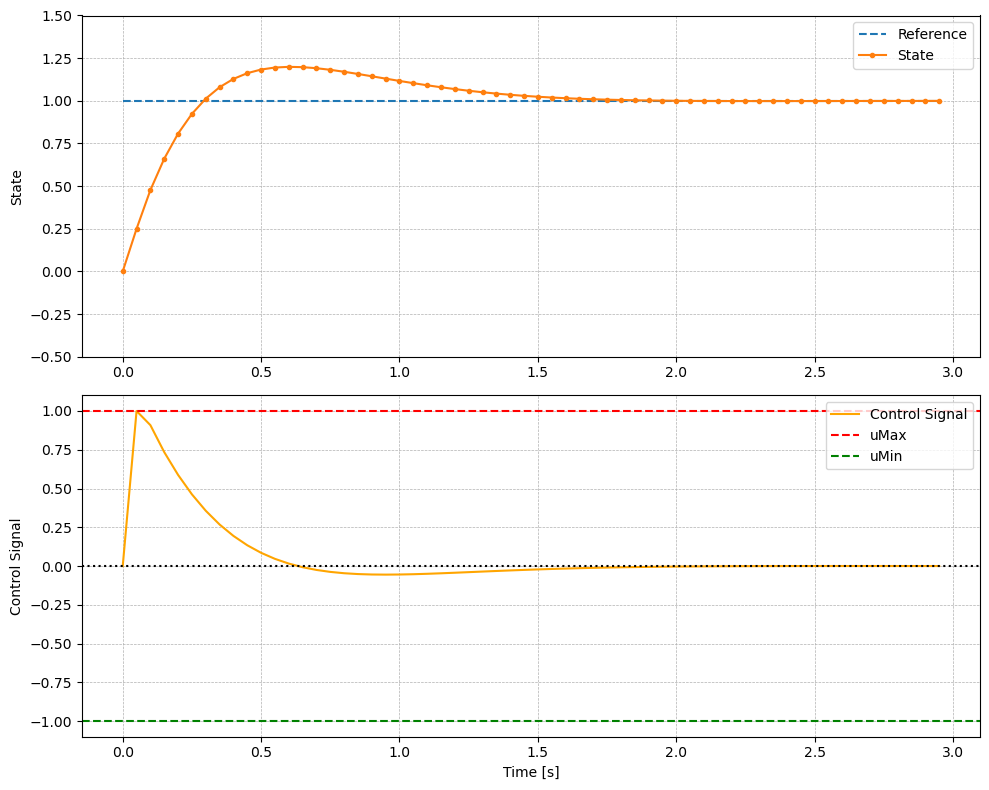

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

plt.subplot(2, 1, 1)
plt.plot(t_vals, ref_vals, label="Reference", linestyle="--")
plt.plot(t_vals, state_vals, label="State", marker="o", markersize=3)
plt.ylabel("State")
plt.ylim(-0.5, 1.5)
plt.grid(which="both", linestyle="--", linewidth=0.5)
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(t_vals, u_vals, label="Control Signal", color="orange")
plt.axhline(y=1.0, color="red", linestyle="--", label="uMax")
plt.axhline(y=-1.0, color="green", linestyle="--", label="uMin")
plt.axhline(y=0.0, color="black", linestyle=":")
plt.xlabel("Time [s]")
plt.ylabel("Control Signal")
plt.legend()
plt.grid(which="both", linestyle="--", linewidth=0.5)

plt.tight_layout()
plt.show()